In [1]:
%load_ext autoreload
%autoreload 2
import importlib 
m = importlib.import_module(".model", "src")
from matplotlib import pyplot as plt
import numpy as np
import xgi
import copy 
plt.style.use("seaborn-whitegrid")

import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap




/tmp/ipykernel_38532/70117239.py:9: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-whitegrid")


In [2]:
dataset = "email-enron"
H = xgi.load_xgi_data(dataset)

/tmp/ipykernel_38532/1671547293.py:7: RuntimeWarning: divide by zero encountered in divide
  v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)
/tmp/ipykernel_38532/1671547293.py:7: RuntimeWarning: invalid value encountered in divide
  v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)


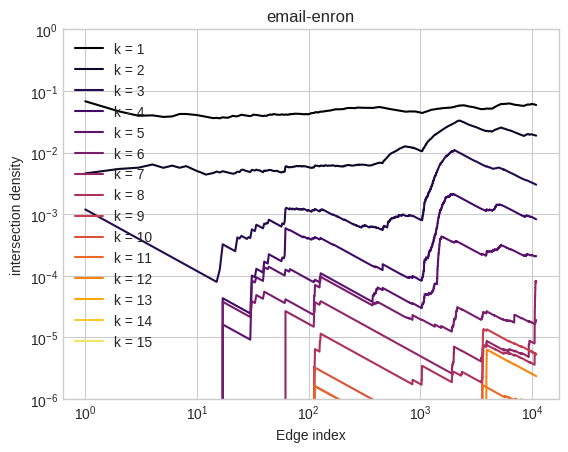

In [3]:
IX = xgi.linalg.hypergraph_matrix.intersection_profile(H).toarray()
np.fill_diagonal(IX, 0)

inferno = mpl.colormaps['inferno'].resampled(IX.max()+1)

for k in range(1, IX.max()+1):
    v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)
    plt.plot(v, label = f"k = {k}", color = inferno(k-1))
    plt.loglog()
plt.legend()
plt.gca().set(xlabel = "Edge index", ylabel = "intersection density", title = dataset)
plt.gca().set_ylim(ymin = 1e-6, ymax = 1e-0)
plt.savefig(f"figures/intersections-{dataset}.png", dpi=300, bbox_inches='tight')

In [4]:
# this seems like a good start
# need to normalize, implement randomization

dataset = "email-enron"
H = xgi.load_xgi_data(dataset)

H = xgi.load_xgi_data(dataset)
GH = m.GrowingHypergraph(H)
=

In [6]:
interval = 10              
D, timesteps = GH.intersection_profile(randomize_eids = False, interval = interval)

randomized eids not implemented yet


TypeError: cannot unpack non-iterable NoneType object

[]

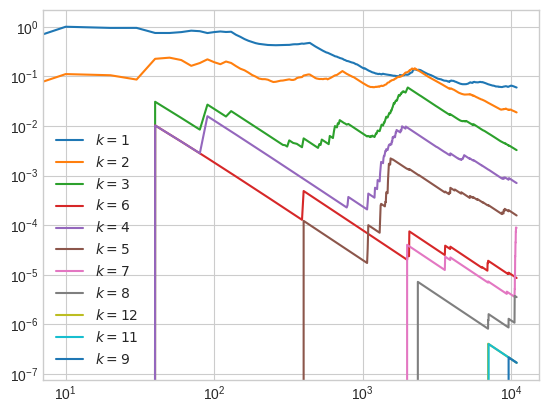

In [133]:
for k in D: 
    plt.plot(timesteps, D[k], label = rf"$k = {k}$")

plt.legend()
plt.loglog()

In [105]:
GH.edge_neighborhood(1)

{0,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 163,
 166,
 167,
 187,
 215,
 249,
 743,
 1348,
 1382,
 1602,
 1817,
 1863,
 1866,
 1867,
 1902,
 1910,
 1915,
 1918,
 1927,
 1935,
 1958,
 1998,
 2309,
 2322,
 2336,
 2341,
 2350,
 2355,
 2359,
 2390,
 2407,
 2408,
 2486,
 3035,
 3036,
 3046,
 3057,
 3059,
 3092,
 3477,
 3478,
 3483,
 3486

In [106]:
mean_degree    = H.nodes.degree.asnumpy().mean()
mean_edge_size = H.edges.size.asnumpy().mean()
num_nodes      = len(H.nodes.degree.asnumpy())
num_edges      =  len(H.edges.size.asnumpy())

print(f"num nodes = {num_nodes}")
print(f"num edges = {num_edges}")
print(f"mean degree = {mean_degree}")
print(f"mean edge size = {mean_edge_size}")


num nodes = 148
num edges = 10885
mean degree = 181.85135135135135
mean edge size = 2.472576940744143


In [107]:
eta   = 0.1   # node retention in edges
gamma = 0.1   # poisson number of nodes from graph
beta  = 0.6   # poisson number of novel nodes

In [108]:
timesteps = int(num_edges)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)

In [109]:
mean_degree    = H.H.nodes.degree.asnumpy().mean()
mean_edge_size = H.H.edges.size.asnumpy().mean()
num_nodes      = len(H.H.nodes.degree.asnumpy())
num_edges      = len(H.H.edges.size.asnumpy())

print(f"num nodes = {num_nodes}")
print(f"num edges = {num_edges}")
print(f"mean degree = {mean_degree}")
print(f"mean edge size = {mean_edge_size}")


num nodes = 6466
num edges = 10887
mean degree = 2.983915867615218
mean edge size = 1.7722053825663635


/tmp/ipykernel_42237/2644570177.py:6: RuntimeWarning: divide by zero encountered in divide
  v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)
/tmp/ipykernel_42237/2644570177.py:6: RuntimeWarning: invalid value encountered in divide
  v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)


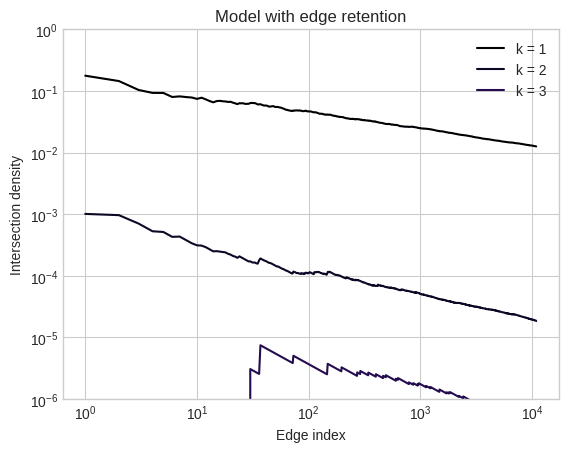

In [110]:
IX = xgi.linalg.hypergraph_matrix.intersection_profile(H.H).toarray()
np.fill_diagonal(IX, 0)

# inferno = mpl.colormaps['inferno'].resampled(IX.max()+1)
for k in range(1, IX.max()+1):
    v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)
    plt.plot(v, label = f"k = {k}", color = inferno(k-1))
    plt.loglog()
plt.legend()
plt.gca().set(xlabel = "Edge index", ylabel = "Intersection density", title = "Model with edge retention")
plt.gca().set_ylim(ymin = 1e-6, ymax = 1e-0)
x = np.arange(100, 1000)
plt.savefig("figures/intersections-model-edge-retention.png", dpi=200, bbox_inches='tight')

# No Edge Selection 

This is a bit hacky at the moment, but does appear to convey the right idea: larger intersection sizes decay at faster rates (though is it $n^k$ rates?)

In [111]:
eta   = 0.0   # node retention in edges
gamma = 0.2     # poisson number of nodes from graph
beta  = 1     # poisson number of novel nodes

timesteps = int(num_edges)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, False)

In [112]:
H.edge_size_sequence().mean()

1.7108090733768022

/tmp/ipykernel_42237/3491402808.py:7: RuntimeWarning: divide by zero encountered in divide
  v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)
/tmp/ipykernel_42237/3491402808.py:7: RuntimeWarning: invalid value encountered in divide
  v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)


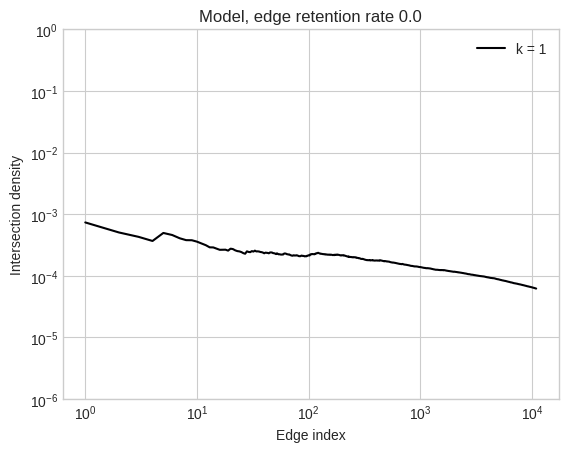

In [113]:
IX = xgi.linalg.hypergraph_matrix.intersection_profile(H.H).toarray()
np.fill_diagonal(IX, 0)

# inferno = mpl.colormaps['inferno'].resampled(IX.max()+1)

for k in range(1, IX.max()+1):
    v = (np.cumsum(IX == k, axis = 1) / np.arange(IX.shape[0])).mean(axis = 0)
    plt.plot(v, label = f"k = {k}", color = inferno(k-1))
    plt.loglog()
plt.gca().set_ylim(ymin = 1e-6, ymax = 1e-0)
# x = np.arange(100, 1000)
# plt.plot(x, (1.0*x)**(-1), color = "black")
plt.legend()
plt.gca().set(xlabel = "Edge index", ylabel = "Intersection density", title = "Model, edge retention rate 0.0")
plt.savefig("figures/intersections-model-no-edge-retention.png", dpi=200, bbox_inches='tight')

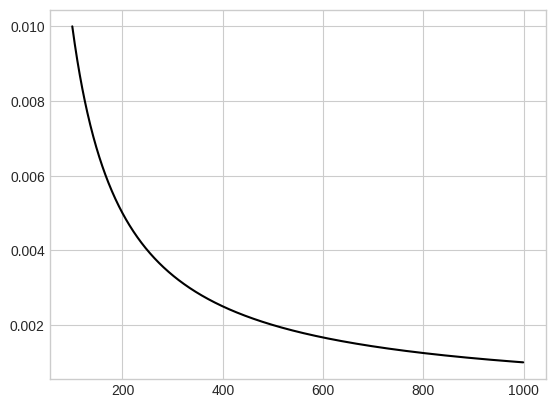

In [114]:
x = np.arange(100, 1000)
plt.plot(x, 1/x, color = "black")